In [85]:
import sourcecode.setup as setup
from sourcecode.main import process_tiff
from sourcecode.config import *
import time


from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Image

from sourcecode.config import *

# Create directory structure
#setup.create_directory_structure()

In [86]:
# List available TIFF files
def list_input_files():
    tiff_files = list(INPUT_DIR.glob("*.tif"))
    print("Available TIFF files:")
    if not tiff_files:
        print("No TIFF files found in Input directory")
        print(f"Please place TIFF files in: {INPUT_DIR}")
    else:
        for i, file in enumerate(tiff_files):
            print(f"{i+1}. {file.name}")
    return tiff_files

tiff_files = list_input_files()

# Display available SAM models
print("\nSAM models:")
for model in SAM_MODELS.keys():
    print(f"- {model}")

Available TIFF files:
1. AR1_K.tif

SAM models:
- vit_h
- vit_l
- vit_b


In [87]:
def process_file(file_index, frame_range=None, model_type="vit_h"):
    """Process a single TIFF file with specified parameters."""
    if not tiff_files:
        print("No files available to process")
        return
    
    if file_index >= len(tiff_files):
        print(f"Invalid file index. Please choose between 0 and {len(tiff_files)-1}")
        return
    
    print(f"Processing {tiff_files[file_index].name}...")
    process_tiff(tiff_files[file_index], frame_range=frame_range, model_type=model_type)
    print("Processing complete!")

# Example: Process first file, first 10 frames
# Uncomment and modify parameters as needed
process_file(file_index=0, frame_range=(0, 1), model_type="vit_h")

Processing AR1_K.tif...

Initializing processing for: AR1_K.tif


Setup:   0%|          | 0/3 [00:00<?, ?it/s]

Using device: cpu


Using existing weights from: /Users/blackvision/Desktop/proj_wbc/sam2/Data/Sam/samweights/sam_vit_h_4b8939.pth






Reading TIFF file: 0it [00:00, ?it/s]               

...

Found 8765 frames
Processing frames 0 to 1


Overall Progress:   0%|          | 0/1 [00:00<?, ?it/s]




Generated 78 masks






Logging experiment:   0%|          | 0/1 [00:00<?, ?it/s]

                                                         

Detailed log saved to: /Users/blackvision/Desktop/proj_wbc/sam2/Data/Sam/samlogs/AR1_K_1.json

Processing completed in 101.36 seconds
Average time per frame: 101.14 seconds
Results saved to: /Users/blackvision/Desktop/proj_wbc/sam2/Data/Sam/samoutputs/AR1_K/15
Processing complete!


In [88]:
def display_results(file_index, max_frames=5):
    """Display processed frames for a specific file."""
    if not tiff_files or file_index >= len(tiff_files):
        print("Invalid file index")
        return
    
    base_name = tiff_files[file_index].stem
    output_dirs = sorted(list((SAM_OUTPUTS_DIR / base_name).glob("*")))
    
    if not output_dirs:
        print("No processed results found")
        return
    
    latest_output = output_dirs[-1]
    frame_files = sorted(list(latest_output.glob("frame_*.png")))
    
    for i, frame_file in enumerate(frame_files[:max_frames]):
        plt.figure(figsize=(8, 8))
        plt.title(f"Frame {i}")
        img = plt.imread(frame_file)
        plt.imshow(img)
        plt.axis('off')
        plt.show()

# Example: Display results for first file
# Uncomment to view results
# display_results(file_index=0, max_frames=5)


Experiment Summary:
--------------------------------------------------
Total experiments: 12
Models used: vit_h
Average processing time per frame: 163.60 seconds


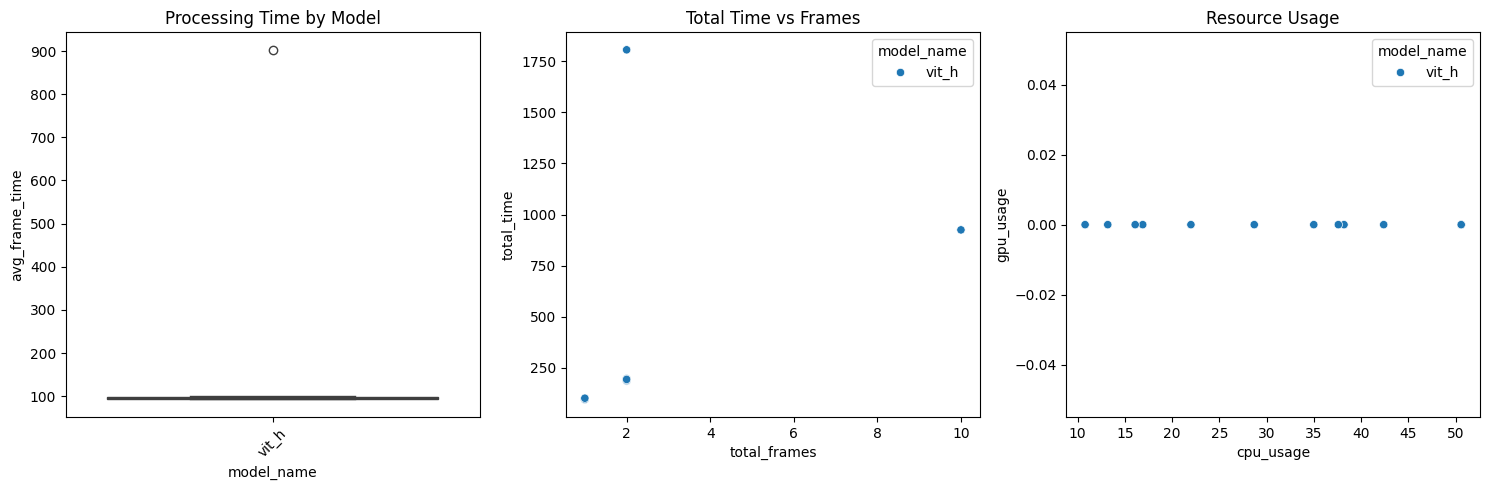

In [89]:
def analyze_experiments():
    """Analyze and display experiment statistics."""
    exp_log_file = EXPERIMENTAL_LOGS_DIR / "experiments.csv"
    
    if not exp_log_file.exists():
        print("No experiment logs found")
        return
    
    df = pd.read_csv(exp_log_file)
    
    # Display summary statistics
    print("\nExperiment Summary:")
    print("-" * 50)
    print(f"Total experiments: {len(df)}")
    print(f"Models used: {', '.join(df['model_name'].unique())}")
    print(f"Average processing time per frame: {df['avg_frame_time'].mean():.2f} seconds")
    
    # Create visualizations
    plt.figure(figsize=(15, 5))
    
    # Processing time by model
    plt.subplot(1, 3, 1)
    sns.boxplot(data=df, x='model_name', y='avg_frame_time')
    plt.title('Processing Time by Model')
    plt.xticks(rotation=45)
    
    # Total time vs frames
    plt.subplot(1, 3, 2)
    sns.scatterplot(data=df, x='total_frames', y='total_time', hue='model_name')
    plt.title('Total Time vs Frames')
    
    # Resource usage
    plt.subplot(1, 3, 3)
    sns.scatterplot(data=df, x='cpu_usage', y='gpu_usage', hue='model_name')
    plt.title('Resource Usage')
    
    plt.tight_layout()
    plt.show()
    
    return df

# Analyze experiments
df = analyze_experiments()

In [91]:
def batch_process(file_indices=None, frame_range=None, model_type="vit_h"):
    """Process multiple files in batch."""
    if file_indices is None:
        file_indices = range(len(tiff_files))
    
    for idx in file_indices:
        if idx < len(tiff_files):
            print(f"\nProcessing {tiff_files[idx].name}...")
            process_file(idx, frame_range, model_type)
    
    print("\nBatch processing complete!")

# Example: Process multiple files
# Uncomment and modify as needed
#batch_process(file_indices=[0, 1], frame_range=(0, 20), model_type="vit_h")


Processing AR1_K.tif...
Processing AR1_K.tif...

Initializing processing for: AR1_K.tif


Setup:   0%|          | 0/3 [00:00<?, ?it/s]

Using device: cpu


Using existing weights from: /Users/blackvision/Desktop/proj_wbc/sam2/Data/Sam/samweights/sam_vit_h_4b8939.pth


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/segment_anything/build_sam.py:105: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict =

Reading TIFF file: /Users/blackvision/Desktop/proj_wbc/sam2/Data/Input/AR1_K.tif


Found 8765 frames
Processing frames 0 to 20


Overall Progress:   0%|          | 0/20 [00:00<?, ?it/s]

Overall Progress:   0%|          | 0/20 [00:09<?, ?it/s]


KeyboardInterrupt: 